# Image classifier (PyTorch)
This notebook loads a pretrained ResNet50, preprocesses an input image, and displays the top predictions. Update the `image_path` in the example cell and run the cells in order.

In [1]:
import urllib.request
from pathlib import Path
from PIL import Image
from IPython.display import display
import torch
from torchvision import models, transforms

In [2]:
LABELS_URL = 'https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt'

def load_labels(path=None):
    if path:
        p = Path(path)
        if p.exists():
            return [l.strip() for l in p.read_text(encoding='utf-8').splitlines()]
    try:
        data = urllib.request.urlopen(LABELS_URL, timeout=5).read().decode('utf-8').splitlines()
        return data
    except Exception:
        return [str(i) for i in range(1000)]

def predict(image_path, topk=5, use_cuda=False):
    device = torch.device('cuda' if use_cuda and torch.cuda.is_available() else 'cpu')

    model = models.resnet50(pretrained=True)
    model.eval().to(device)

    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    img = Image.open(image_path).convert('RGB')
    input_tensor = preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(input_tensor)
        probs = torch.nn.functional.softmax(out[0], dim=0)
        top_probs, top_idxs = probs.topk(topk)

    labels = load_labels(None)
    results = []
    for prob, idx in zip(top_probs.tolist(), top_idxs.tolist()):
        label = labels[idx] if idx < len(labels) else str(idx)
        results.append((label, float(prob)))
    return results

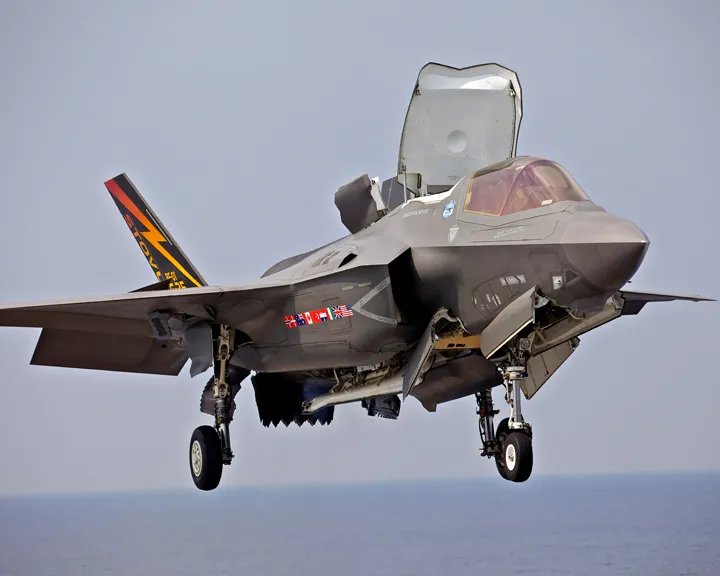

warplane: 0.9562
aircraft carrier: 0.0357
wing: 0.0021
airliner: 0.0012
stretcher: 0.0011


In [4]:
# Example: set `image_path` to a local image and run this cell
# image_path = 'C:\\Users\\Aniket Ghoshal\\Downloads\\photo-1552728089-57bdde30beb3.avif'  # <- update this path
# image_path = 'C:\\Users\\Aniket Ghoshal\\Downloads\\Persialainen.jpg'
image_path = 'C:\\Users\\Aniket Ghoshal\\Downloads\\f35-jsf-1.webp'

# Display image (if available)
if Path(image_path).exists():
    display(Image.open(image_path))
else:
    print('Image not found at', image_path)

# Run prediction (set use_cuda=True to attempt GPU)
results = predict(image_path, topk=5, use_cuda=False)
for label, prob in results:
    print(f'{label}: {prob:.4f}')